In [1]:
import sys
sys.path.append('../..') 
from ecgxaiY.systems.VAE_system import GaussianVAE
from ecgxaiY.network.causalcnn.vae import VAE
import os
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, auc

import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.transforms import Compose

import pytorch_lightning as pl
from pytorch_lightning.loggers.neptune import NeptuneLogger
from pytorch_lightning.callbacks import ModelCheckpoint


from ecgxaiY.utils.dataset import UniversalECGDataset
from ecgxaiY.utils.transforms import ApplyGain, ToTensor, To12Lead, Resample
from ecgxaiY.systems.classification_system import ClassificationSystem
from ecgxaiY.utils.loss import CombinedLoss, GaussianVAEReconLoss, KLDivergence, BinaryFocalLoss

In [2]:
def get_prediction(model, df):
    transform = transforms.Compose([ApplyGain(), ToTensor()])
    
    dataset = UniversalECGDataset(
        dataset_function="umcu",
        waveform_dir="/home/ubuntu/djboo/FactorECG/TMT/Datasets/TMT_waveform",
        dataset=df,
        transform=transform
    )
    
    dataloader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=8)
    
    output = trainer.predict(model, dataloaders=dataloader)
    
    y = torch.cat([x["label"] for x in output], dim=0).cpu().numpy()
    y_prob = torch.cat([x["y_prob"] for x in output], dim=0).cpu().numpy()

    return y, y_prob

In [3]:
def bootstrap_ci(metric, label, y_prob):
    boot_metric = []
    boot_df = pd.DataFrame({'label': label, 'y_prob': y_prob})

    for i in range(2000):
        boot = boot_df.sample(frac = 1, replace = True).reset_index(drop=True)
        metric_value = metric(boot['label'], boot['y_prob'])
        boot_metric.append(metric_value)

    print('C-stat CI: ' + str(np.quantile(boot_metric,q=0.025,axis=0)) + ' ' + str(np.quantile(boot_metric,q=0.975,axis=0)))

In [4]:
trainer = pl.Trainer(logger=False, gpus=1)

GPU available: True, used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs


## Initialize models

In [6]:
vae_stage1 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC6-1/epoch=epoch=22-step=step=9222-loss=val_loss=-7492.71.ckpt")

{'mu', 'reconstruction_mean', 'reconstruction_std', 'x', 'std'}


In [7]:
vae_stage2 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC7-1/epoch=epoch=14-step=step=5984-loss=val_loss=-7319.12.ckpt")

{'mu', 'reconstruction_mean', 'reconstruction_std', 'x', 'std'}


In [8]:
vae_stage3 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC8-1/epoch=epoch=13-step=step=5067-loss=val_loss=-7205.83.ckpt")

{'mu', 'reconstruction_mean', 'reconstruction_std', 'x', 'std'}


In [9]:
vae_stage4 = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC9-1/epoch=epoch=15-step=step=3071-loss=val_loss=-7053.12.ckpt")

{'mu', 'reconstruction_mean', 'reconstruction_std', 'x', 'std'}


In [10]:
vae_stageR = GaussianVAE.load_from_checkpoint(checkpoint_path="/home/ubuntu/djboo/FactorECG/VAE/FAC10-1/epoch=epoch=10-step=step=27378-loss=val_loss=-7639.63.ckpt")

{'mu', 'reconstruction_mean', 'reconstruction_std', 'x', 'std'}


## Get data and dataloaders

In [16]:
from sklearn.model_selection import train_test_split
testset_path = '/home/ubuntu/djboo/FactorECG/VAE/TMT/240208_yuhs_test_r1.csv'
df_test = pd.read_csv(testset_path)
df_test[["PseudoID", "stage"]].groupby("stage").count()

,PseudoID
stage,
#1,1362
#2,1365
#3,1274
#4,1
#5,1
SITTING,435
STAGE 1,1343
STAGE 2,1353
STAGE 3,1307


In [57]:
len(df_test["PseudoID"].unique())

1368

In [25]:
df_test_stage1=df_test[df_test['stage'].str.contains('STAGE 1')].reset_index(drop=True)
df_test_stage2=df_test[df_test['stage'].str.contains('STAGE 2')].reset_index(drop=True)
df_test_stage3=df_test[df_test['stage'].str.contains('STAGE 3')].reset_index(drop=True)
df_test_stage4=df_test[df_test['stage'].str.contains('STAGE 4')].reset_index(drop=True)
df_test_stageR=df_test[df_test['stage'].str.contains('#')].groupby(['PseudoID','AcqDate']).apply(lambda x: x.sample(1)).reset_index(drop=True)

In [26]:
latent_rep_df_test_s1, waveforms_test_s1, reconstructions_test_s1 = get_latents(vae_stage1, df_test_stage1)
latent_rep_df_test_s2, waveforms_test_s2, reconstructions_test_s2 = get_latents(vae_stage2, df_test_stage2)
latent_rep_df_test_s3, waveforms_test_s3, reconstructions_test_s3 = get_latents(vae_stage3, df_test_stage3)
latent_rep_df_test_s4, waveforms_test_s4, reconstructions_test_s4 = get_latents(vae_stage4, df_test_stage4)
latent_rep_df_test_sR, waveforms_test_sR, reconstructions_test_sR = get_latents(vae_stageR, df_test_stageR)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: 0it [00:00, ?it/s]

1:'I'
2:'II'
3:'III'
4:'aVR'
5:'aVL'
6:'aVF'
7:'V1'
8:'V2'
9:'V3'
10:'V4'
11:'V5'
12:'V6'

In [41]:
import numpy as np
from scipy import stats

def fisher_z_transform(r):
    """Transforms a correlation coefficient to Fisher's Z."""
    return 0.5 * np.log((1 + r) / (1 - r))

def inverse_fisher_z_transform(z):
    """Transforms Fisher's Z back to a correlation coefficient."""
    return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

def process_correlations(correlations):
    """Calculates the mean of Fisher's Z-transformed correlation coefficients, back-transforms it, and calculates p-value."""
    # Step 1: Transform each correlation coefficient to Fisher's Z
    z_values = np.array([fisher_z_transform(r) for r in correlations])
    z_values=z_values[~np.isnan(z_values)]
    # Step 2: Calculate the mean of Z values and its standard error
    mean_z = np.mean(z_values)
    se_z = 1 / np.sqrt(len(correlations) - 3)
    
    # Step 3: Back-transform the mean Z to a correlation coefficient
    mean_correlation = inverse_fisher_z_transform(mean_z)
    
    # Calculate the z-score for the mean correlation
    z_score = mean_z / se_z
    
    # Calculate the p-value for the z-score
    p_value = 2 * (1 - stats.norm.cdf(abs(z_score)))
    
    return mean_correlation, p_value


## Evaluation for stage1

In [42]:
mean_corr_list=[]
for idx in tqdm(range(df_test_stage1.shape[0])):
    corr_list=[]
    for l in range(12):
        target = torch.from_numpy(waveforms_test_s1[idx,l,:])
        preds = torch.from_numpy(reconstructions_test_s1[idx,l,:])
        cor = pearson_corrcoef(preds, target)
        corr_list.append(cor)
    mean_correlation = process_correlations(corr_list)[0]
    mean_corr_list.append(mean_correlation)

# Process the correlations and get the mean correlation and p-value
mean_correlation, p_value = process_correlations(mean_corr_list)
print(f"Mean Correlation (Back-Transformed): {mean_correlation}, P-Value: {p_value}")

  0%|          | 0/1343 [00:00<?, ?it/s]

Mean Correlation (Back-Transformed): 0.9347208716990301, P-Value: 0.0


idx:1133/corr: 0.9693588614463806


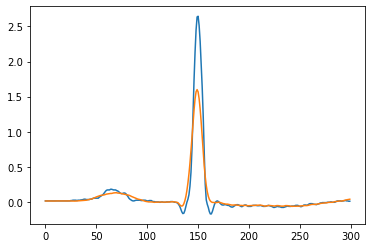

idx:56/corr: 0.9526196122169495


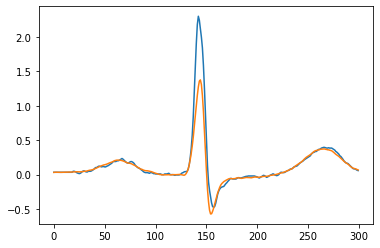

idx:406/corr: 0.9447201490402222


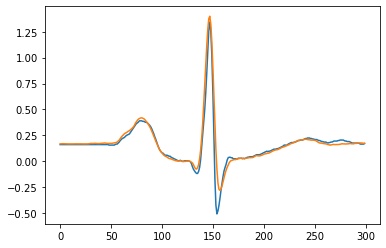

idx:830/corr: 0.9051665663719177


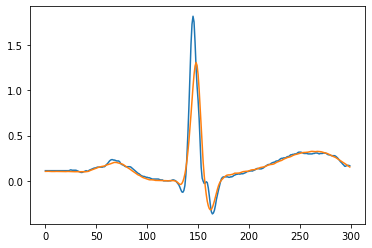

idx:666/corr: 0.8725677132606506


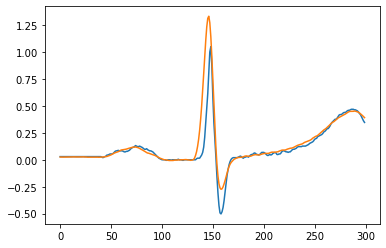

idx:1276/corr: 0.9787702560424805


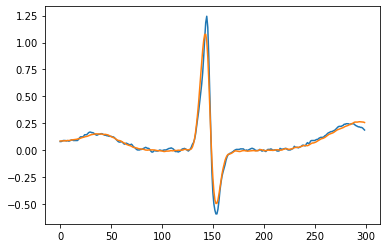

idx:92/corr: 0.9189991354942322


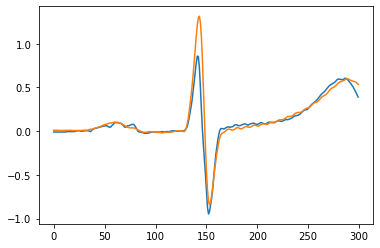

idx:1042/corr: 0.8723527789115906


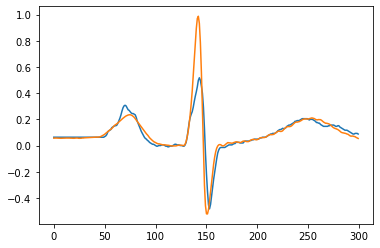

idx:1310/corr: 0.9040664434432983


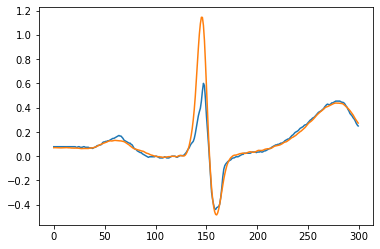

idx:606/corr: 0.9203733205795288


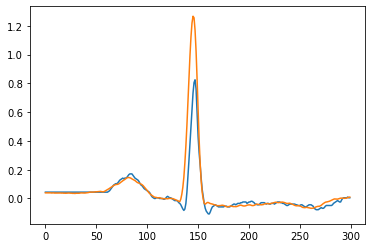

idx:680/corr: 0.9273646473884583


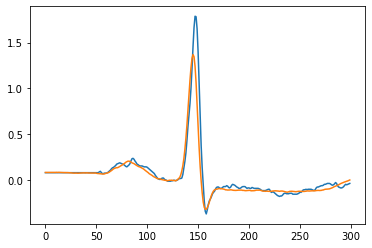

idx:913/corr: 0.9759732484817505


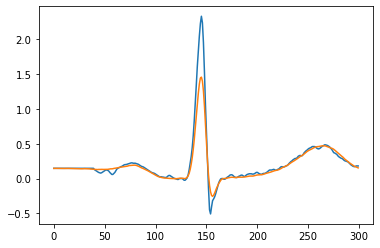

idx:365/corr: 0.9381895661354065


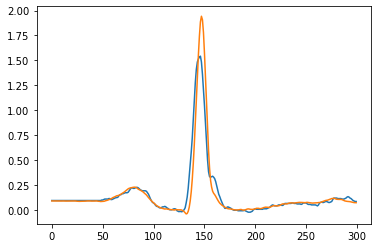

idx:1109/corr: 0.9864324927330017


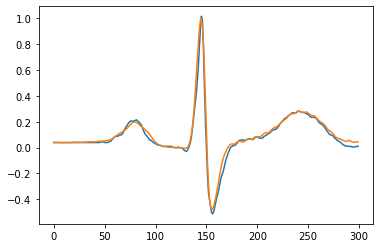

idx:845/corr: 0.9855226278305054


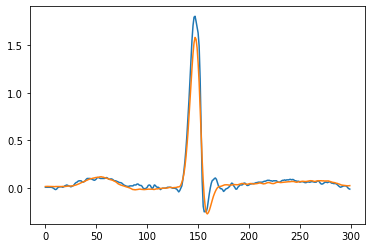

In [45]:
for _ in range(15):
    idx_test = np.random.randint(df_test_stage1.shape[0])
    target = torch.from_numpy(waveforms_test_s1[idx_test,1,:])
    preds = torch.from_numpy(reconstructions_test_s1[idx_test,1,:])
    cor=pearson_corrcoef(preds, target)
    print(f'idx:{idx_test}/corr: {cor}')
    plt.plot(waveforms_test_s1[idx_test,1,:])
    plt.plot(reconstructions_test_s1[idx_test,1,:])
    plt.show()

## Evaluation for stage2

In [55]:
mean_corr_list2=[]
for idx in tqdm(range(df_test_stage2.shape[0])):
    corr_list=[]
    for l in range(12):
        target = torch.from_numpy(waveforms_test_s2[idx,l,:])
        preds = torch.from_numpy(reconstructions_test_s2[idx,l,:])
        cor = pearson_corrcoef(preds, target)
        corr_list.append(cor)
    mean_correlation = process_correlations(corr_list)[0]
    mean_corr_list2.append(mean_correlation)

# Process the correlations and get the mean correlation and p-value
mean_correlation, p_value = process_correlations(mean_corr_list2)
print(f"Mean Correlation (Back-Transformed): {mean_correlation}, P-Value: {p_value}")

  0%|          | 0/1353 [00:00<?, ?it/s]

Mean Correlation (Back-Transformed): 0.9331190953838622, P-Value: 0.0


idx:424/corr: 0.9482629299163818


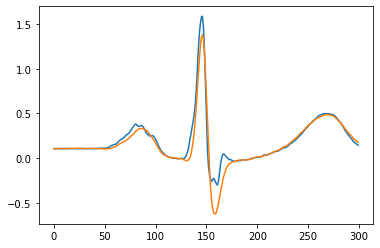

idx:926/corr: 0.9854761362075806


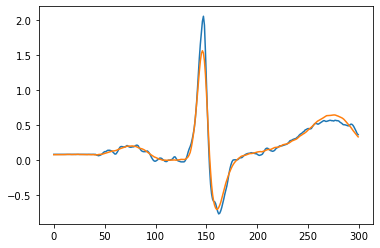

idx:776/corr: 0.858086347579956


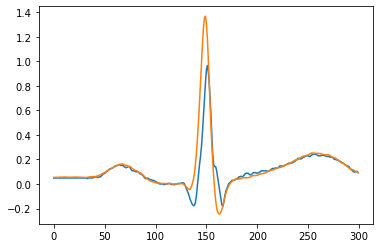

idx:467/corr: 0.9708212018013


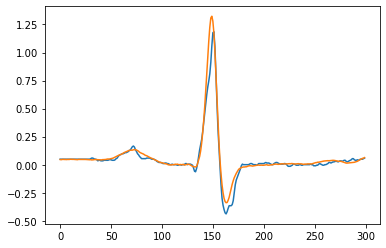

idx:1088/corr: 0.8361623287200928


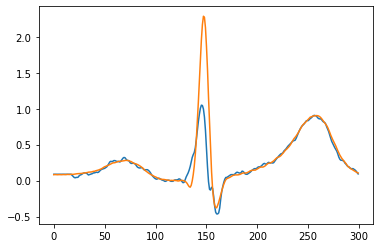

idx:977/corr: 0.9798920154571533


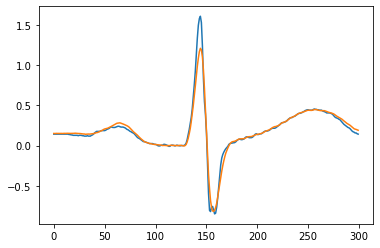

idx:606/corr: 0.9880886077880859


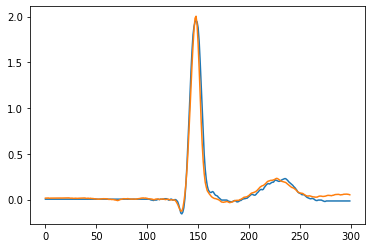

idx:974/corr: 0.9869364500045776


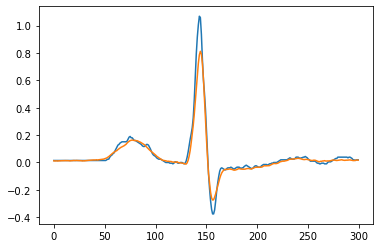

idx:156/corr: 0.8455281257629395


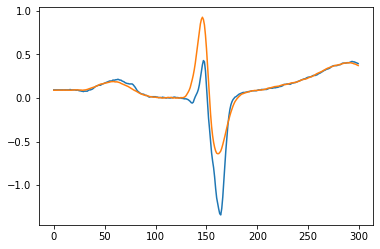

idx:1055/corr: 0.8501569628715515


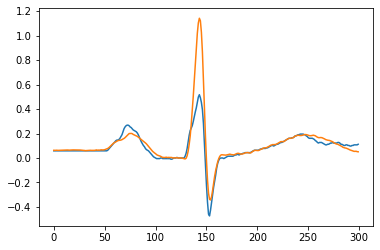

idx:186/corr: 0.9791615009307861


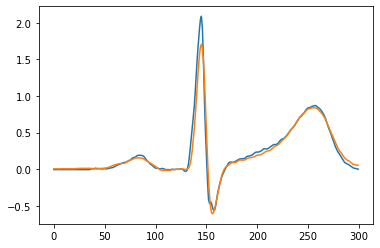

idx:403/corr: 0.9533820152282715


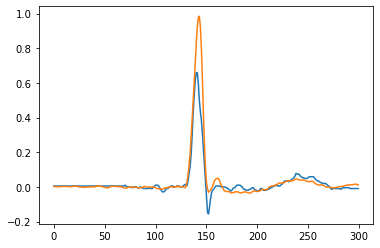

idx:307/corr: 0.9628574848175049


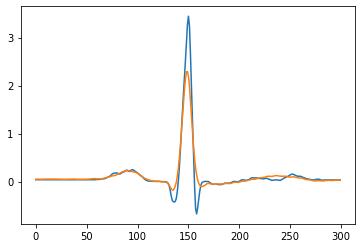

idx:1223/corr: 0.9425320029258728


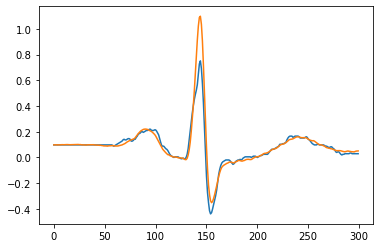

idx:54/corr: 0.8944422602653503


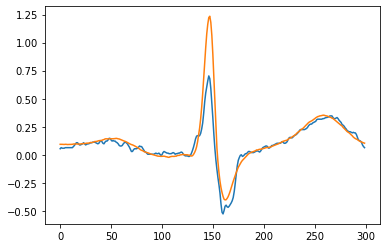

In [56]:
for _ in range(15):
    idx_test = np.random.randint(df_test_stage2.shape[0])
    target = torch.from_numpy(waveforms_test_s2[idx_test,1,:])
    preds = torch.from_numpy(reconstructions_test_s2[idx_test,1,:])
    cor=pearson_corrcoef(preds, target)
    print(f'idx:{idx_test}/corr: {cor}')
    plt.plot(waveforms_test_s2[idx_test,1,:])
    plt.plot(reconstructions_test_s2[idx_test,1,:])
    plt.show()

## Evaluation for stage3

In [49]:
mean_corr_list3=[]
for idx in tqdm(range(df_test_stage3.shape[0])):
    corr_list=[]
    for l in range(12):
        target = torch.from_numpy(waveforms_test_s3[idx,l,:])
        preds = torch.from_numpy(reconstructions_test_s3[idx,l,:])
        cor = pearson_corrcoef(preds, target)
        corr_list.append(cor)
    mean_correlation = process_correlations(corr_list)[0]
    mean_corr_list3.append(mean_correlation)

# Process the correlations and get the mean correlation and p-value
mean_correlation, p_value = process_correlations(mean_corr_list3)
print(f"Mean Correlation (Back-Transformed): {mean_correlation}, P-Value: {p_value}")

  0%|          | 0/1307 [00:00<?, ?it/s]

Mean Correlation (Back-Transformed): 0.9344687219440166, P-Value: 0.0


idx:119/corr: 0.685664713382721


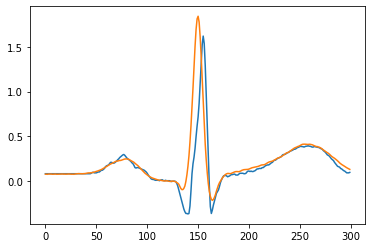

idx:115/corr: 0.9902192950248718


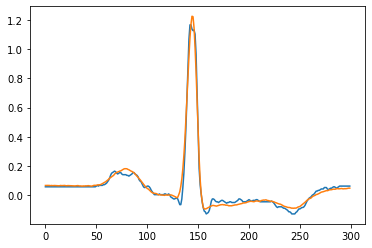

idx:104/corr: 0.9558923244476318


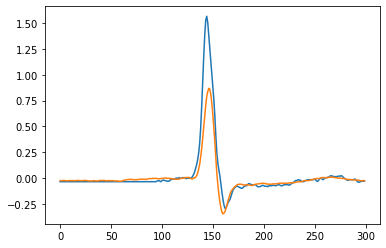

idx:1278/corr: 0.9777149558067322


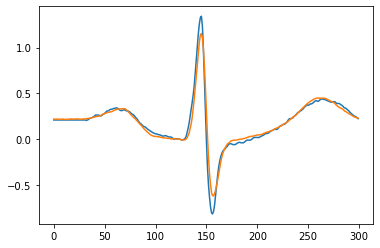

idx:512/corr: 0.9484167695045471


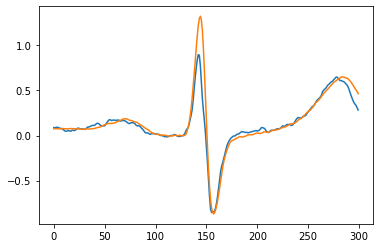

idx:388/corr: 0.9707104563713074


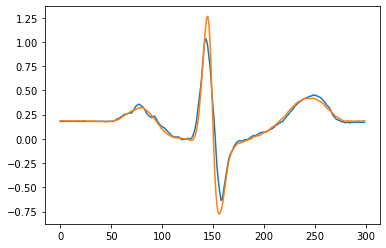

idx:160/corr: 0.9694268703460693


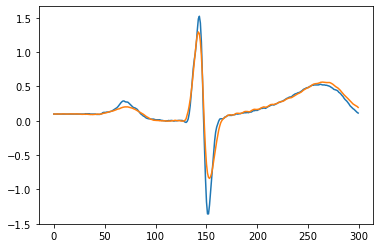

idx:1127/corr: 0.9479789733886719


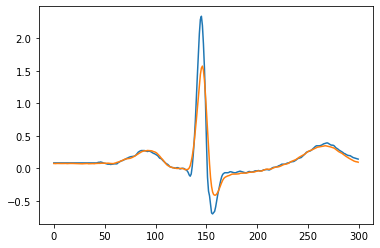

idx:641/corr: 0.9865506887435913


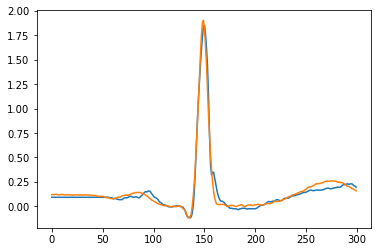

idx:504/corr: 0.8750933408737183


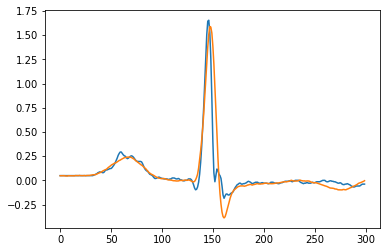

idx:1089/corr: 0.9789916276931763


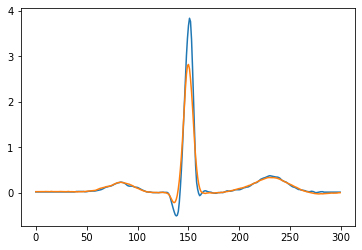

idx:139/corr: 0.8331162929534912


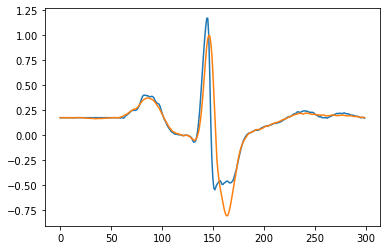

idx:1289/corr: 0.8160488605499268


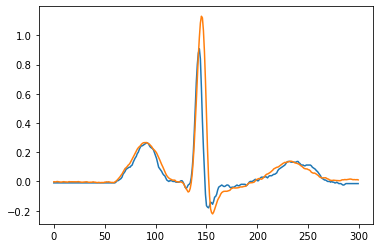

idx:499/corr: 0.9865285754203796


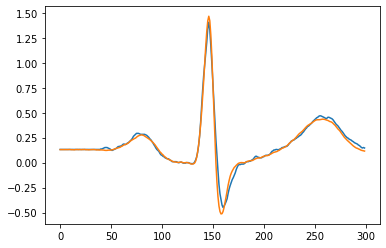

idx:728/corr: 0.9735232591629028


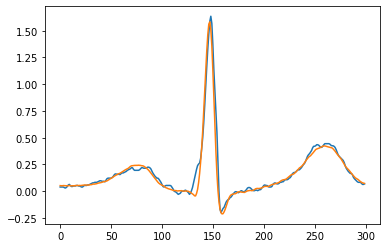

In [50]:
for _ in range(15):
    idx_test = np.random.randint(df_test_stage3.shape[0])
    target = torch.from_numpy(waveforms_test_s3[idx_test,1,:])
    preds = torch.from_numpy(reconstructions_test_s3[idx_test,1,:])
    cor=pearson_corrcoef(preds, target)
    print(f'idx:{idx_test}/corr: {cor}')
    plt.plot(waveforms_test_s3[idx_test,1,:])
    plt.plot(reconstructions_test_s3[idx_test,1,:])
    plt.show()

## Evaluation for stage4

In [51]:
mean_corr_list4=[]
for idx in tqdm(range(df_test_stage4.shape[0])):
    corr_list=[]
    for l in range(12):
        target = torch.from_numpy(waveforms_test_s4[idx,l,:])
        preds = torch.from_numpy(reconstructions_test_s4[idx,l,:])
        cor = pearson_corrcoef(preds, target)
        corr_list.append(cor)
    mean_correlation = process_correlations(corr_list)[0]
    mean_corr_list4.append(mean_correlation)

# Process the correlations and get the mean correlation and p-value
mean_correlation, p_value = process_correlations(mean_corr_list4)
print(f"Mean Correlation (Back-Transformed): {mean_correlation}, P-Value: {p_value}")

  0%|          | 0/926 [00:00<?, ?it/s]

Mean Correlation (Back-Transformed): 0.9339593413552384, P-Value: 0.0


idx:519/corr: 0.9829726815223694


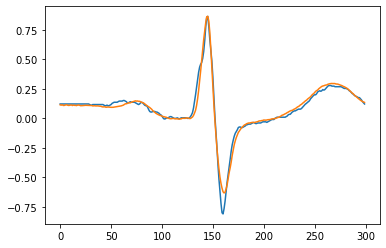

idx:76/corr: 0.9057300090789795


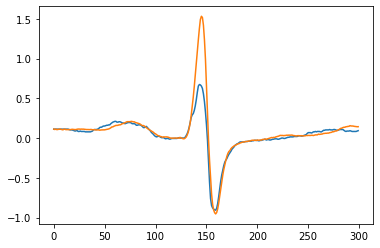

idx:256/corr: 0.9089780449867249


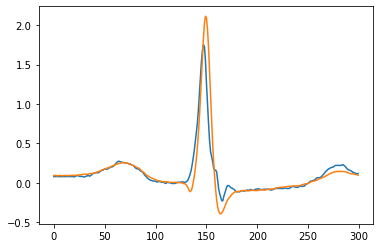

idx:320/corr: 0.9208173155784607


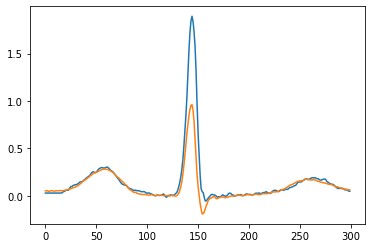

idx:692/corr: 0.9402369260787964


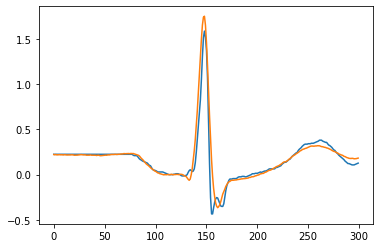

idx:851/corr: 0.9231287837028503


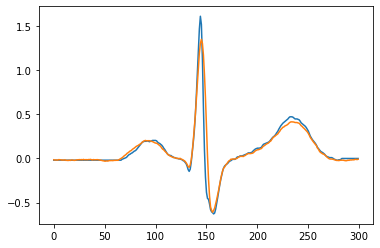

idx:549/corr: 0.9606620073318481


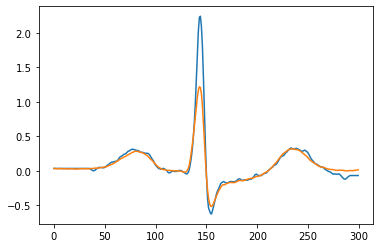

idx:40/corr: 0.527701199054718


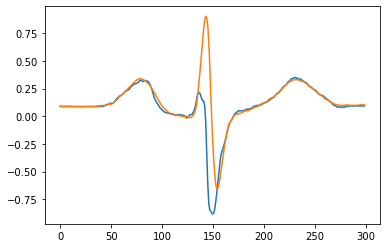

idx:485/corr: 0.8690215945243835


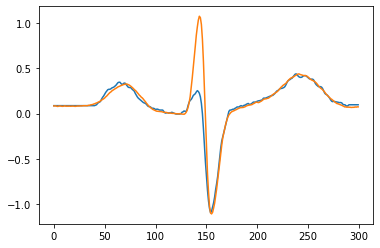

idx:70/corr: 0.9744986295700073


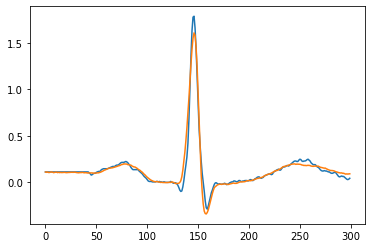

idx:289/corr: 0.9731823801994324


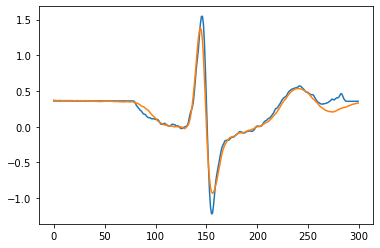

idx:824/corr: 0.9349368214607239


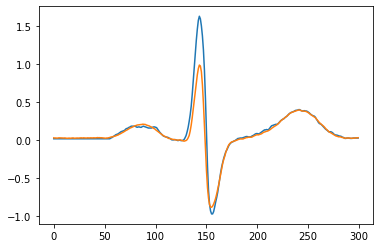

idx:56/corr: 0.9867557883262634


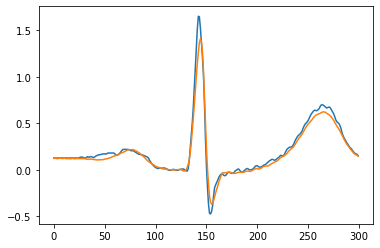

idx:639/corr: 0.9601803421974182


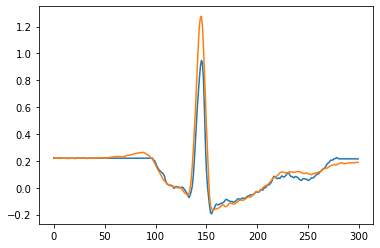

idx:304/corr: 0.9319132566452026


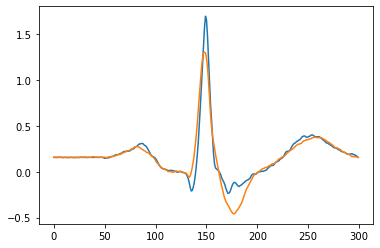

In [52]:
for _ in range(15):
    idx_test = np.random.randint(df_test_stage4.shape[0])
    target = torch.from_numpy(waveforms_test_s4[idx_test,1,:])
    preds = torch.from_numpy(reconstructions_test_s4[idx_test,1,:])
    cor=pearson_corrcoef(preds, target)
    print(f'idx:{idx_test}/corr: {cor}')
    plt.plot(waveforms_test_s4[idx_test,1,:])
    plt.plot(reconstructions_test_s4[idx_test,1,:])
    plt.show()

## Evaluation for stage Resting

In [53]:
mean_corr_listR=[]
for idx in tqdm(range(df_test_stageR.shape[0])):
    corr_list=[]
    for l in range(12):
        target = torch.from_numpy(waveforms_test_sR[idx,l,:])
        preds = torch.from_numpy(reconstructions_test_sR[idx,l,:])
        cor = pearson_corrcoef(preds, target)
        corr_list.append(cor)
    mean_correlation = process_correlations(corr_list)[0]
    mean_corr_listR.append(mean_correlation)

# Process the correlations and get the mean correlation and p-value
mean_correlation, p_value = process_correlations(mean_corr_listR)
print(f"Mean Correlation (Back-Transformed): {mean_correlation}, P-Value: {p_value}")

  0%|          | 0/1366 [00:00<?, ?it/s]

Mean Correlation (Back-Transformed): 0.9413180379614573, P-Value: 0.0


idx:932/corr: 0.8998463153839111


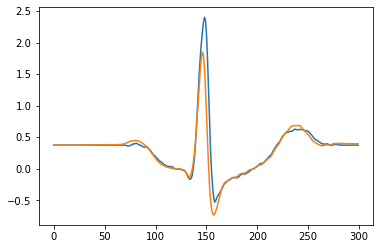

idx:165/corr: 0.9804696440696716


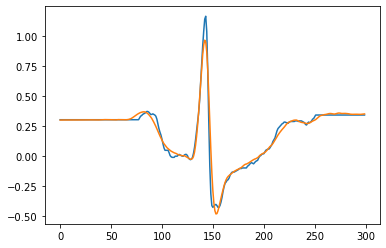

idx:342/corr: 0.935318648815155


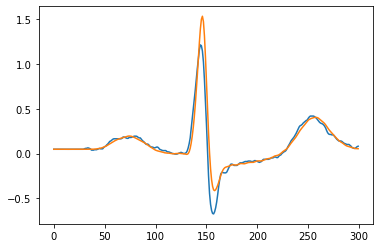

idx:1331/corr: 0.9354171752929688


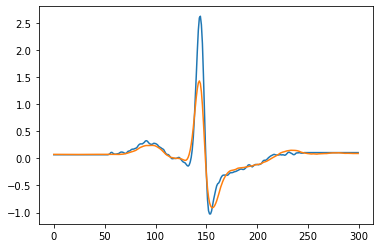

idx:577/corr: 0.7296633720397949


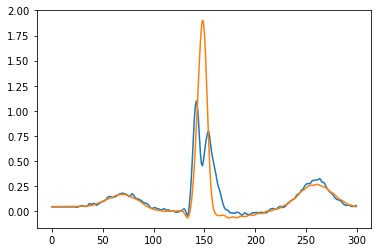

idx:831/corr: 0.9844013452529907


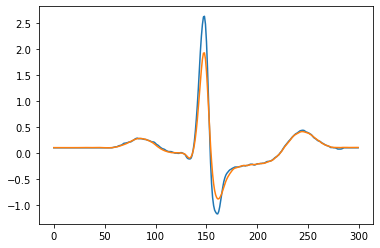

idx:595/corr: 0.9787615537643433


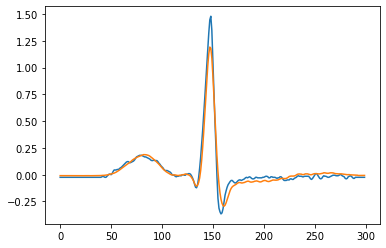

idx:1004/corr: 0.9928046464920044


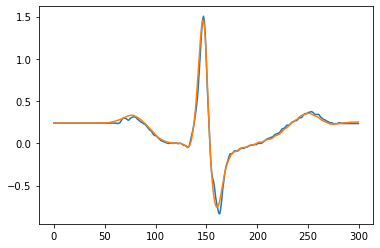

idx:1032/corr: 0.9907670617103577


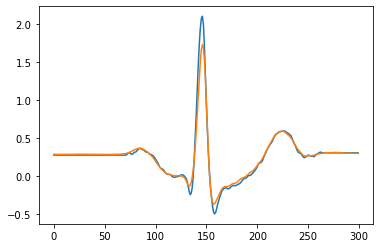

idx:505/corr: 0.9759044051170349


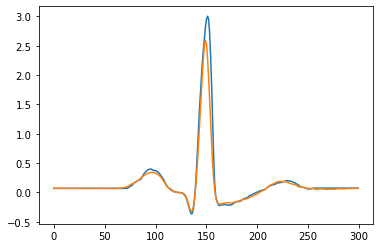

idx:73/corr: 0.9909212589263916


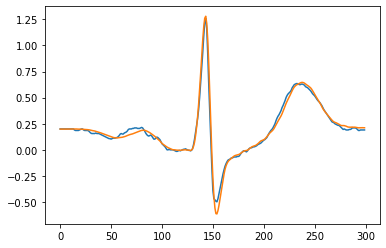

idx:1034/corr: 0.9925846457481384


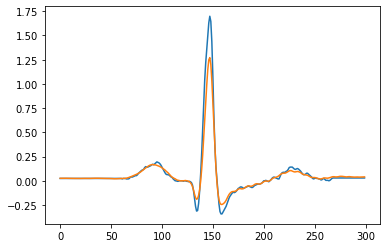

idx:141/corr: 0.9535912275314331


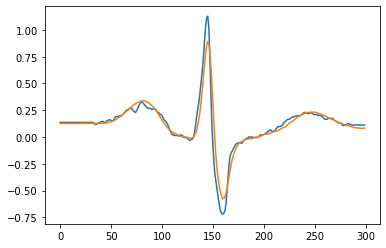

idx:291/corr: 0.9416564702987671


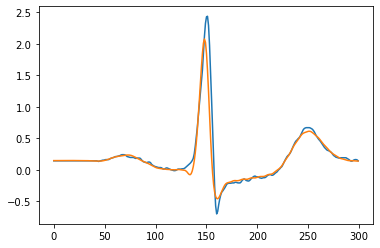

idx:646/corr: 0.9719803333282471


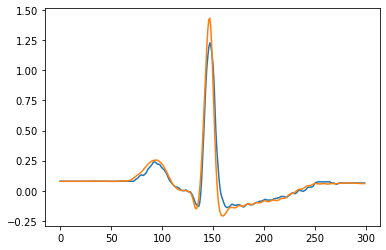

In [54]:
for _ in range(15):
    idx_test = np.random.randint(df_test_stageR.shape[0])
    target = torch.from_numpy(waveforms_test_sR[idx_test,1,:])
    preds = torch.from_numpy(reconstructions_test_sR[idx_test,1,:])
    cor=pearson_corrcoef(preds, target)
    print(f'idx:{idx_test}/corr: {cor}')
    plt.plot(waveforms_test_sR[idx_test,1,:])
    plt.plot(reconstructions_test_sRㅋㅇㅇ[idx_test,1,:])
    plt.show()